# Week 9: Medical Image Segmentation with AI
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Distinguish segmentation from classification and detection, and explain when each is needed clinically
2. Describe the U-Net encoder-decoder architecture with skip connections
3. Implement and train a U-Net for medical image segmentation using segmentation_models_pytorch
4. Evaluate segmentation quality using Dice coefficient, IoU, and Hausdorff distance
5. Design an annotation workflow using active learning for efficient labeling

**Tools:** Google Colab (GPU required) + Gemini AI
**Dataset:** ISIC Skin Lesion Segmentation (synthetic fallback included)
**Libraries:** PyTorch, segmentation_models_pytorch, albumentations, matplotlib, sklearn
**Estimated Time:** 40-50 minutes

---

> **Clinical Scenario (Red Thread):** Measuring Ejection Fraction from cardiac
> MRI: a cardiologist manually traces the left ventricle boundary on every
> slice of a cardiac MRI -- 20 minutes per patient. Multiply that by 30
> patients a day. That is 10 hours of contouring alone. Now an AI model draws
> the same boundary in 3 seconds with sub-pixel precision. Over a hospital
> year, that is 5,000+ hours of physician time returned to patient care. But
> the AI needed thousands of expert-traced contours to learn. Who draws those
> training masks? How do you ensure quality? And what architecture can the AI
> use to produce pixel-perfect boundaries?
>
> **This week:** We build a U-Net segmentation model using
> segmentation_models_pytorch, train it on skin lesion data with Dice+BCE
> loss, and evaluate with Dice, IoU, and visual overlays -- the core tools
> behind every clinical segmentation AI system.


## 0. Environment Setup

We need specialized libraries for medical image segmentation:

**Key libraries:**
- **segmentation_models_pytorch (SMP)**: Provides U-Net and other segmentation architectures with pretrained encoders
- **albumentations**: Fast, flexible image augmentation that applies identical transforms to images AND masks
- **torch / torchvision**: Core deep learning framework
- **sklearn**: Train/val/test splitting

**GPU is REQUIRED** for this notebook. Enable it via:
`Runtime > Change runtime type > GPU`

Training a U-Net on ~200 images for 20 epochs takes ~5 minutes on GPU vs 60+ minutes on CPU.


In [1]:
# ============================================================
# Section 0a: Install additional libraries
# ============================================================
!pip install segmentation_models_pytorch albumentations --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# Section 0b: Imports
# ============================================================
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Segmentation models
import segmentation_models_pytorch as smp

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Image handling
from PIL import Image

# Evaluation
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid")

print("All libraries imported successfully!")
print(f"PyTorch:                    {torch.__version__}")
print(f"segmentation_models_pytorch: {smp.__version__}")
print(f"NumPy:                      {np.__version__}")


All libraries imported successfully!
PyTorch:                    2.10.0+cpu
segmentation_models_pytorch: 0.5.0
NumPy:                      2.0.2


In [3]:
# ============================================================
# Section 0c: GPU Check (REQUIRED)
# ============================================================
# This notebook requires GPU for efficient U-Net training.
# Enable it: Runtime > Change runtime type > GPU

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    print(f"GPU Available: {gpu_name}")
    print(f"GPU Memory:    {gpu_mem:.1f} GB")
    print(f"CUDA Version:  {torch.version.cuda}")
    print(f"\nDevice set to: {device}")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected!")
    print("U-Net training will be VERY slow on CPU (~60+ minutes vs ~5 minutes on GPU).")
    print("Please enable GPU: Runtime > Change runtime type > GPU")
    print(f"\nDevice set to: {device} (not recommended)")

print(f"\nDevice: {device}")


U-Net training will be VERY slow on CPU (~60+ minutes vs ~5 minutes on GPU).
Please enable GPU: Runtime > Change runtime type > GPU

Device set to: cpu (not recommended)

Device: cpu


In [4]:
# ============================================================
# Section 0d: Set Random Seeds for Reproducibility
# ============================================================
SEED = 42

def set_seed(seed=SEED):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED} for reproducibility.")


Random seed set to 42 for reproducibility.


## 1. Load Skin Lesion Segmentation Data

We create a **synthetic dermoscopy-like dataset** that mimics the structure of
the ISIC Skin Lesion Segmentation Challenge dataset. The real ISIC dataset
requires API access, so we generate a synthetic fallback that preserves the
key properties:

- **Binary segmentation**: Background (0) vs Lesion (1)
- **Elliptical lesion shapes** on noisy skin-colored backgrounds
- **Paired images + masks**: Each image has a corresponding binary mask
- **256x256 resolution** suitable for U-Net training

Each image represents a dermoscopy photograph of a skin lesion -- even synthetic
data preserves the workflow you would use with real clinical images.

**Why skin lesions?** Dermoscopic segmentation is clinically critical:
accurate border detection drives the ABCDE criteria for melanoma screening.
The same U-Net architecture generalizes to cardiac MRI contouring,
brain tumor delineation, and retinal vessel segmentation.

> **Corresponds to Lab 1, Slide S34**


In [5]:
# ============================================================
# Section 1a: Create Synthetic Skin Lesion Dataset
# ============================================================
# We generate synthetic dermoscopy-like images with elliptical lesions.
# In practice, you would use the ISIC Archive or similar clinical dataset.

from skimage.draw import ellipse
from skimage.filters import gaussian

IMG_SIZE = 256
N_SAMPLES = 200
DATA_DIR = "/content/skin_data"

def create_synthetic_skin_dataset(n_samples=200, img_size=256, data_dir="/content/skin_data"):
    """Create synthetic dermoscopy-like images with lesion masks.

    Each image has a skin-colored background with noise,
    and one or more darkened elliptical regions representing lesions.
    The mask marks the lesion pixels as 1 (white) and background as 0 (black).
    """
    os.makedirs(os.path.join(data_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(data_dir, "masks"), exist_ok=True)

    rng = np.random.RandomState(SEED)

    for i in range(n_samples):
        # Skin-colored background with realistic variation
        r_base = rng.randint(160, 210)
        g_base = rng.randint(130, 180)
        b_base = rng.randint(100, 150)
        bg = np.zeros((img_size, img_size, 3), dtype=np.float64)
        bg[:, :, 0] = r_base + rng.normal(0, 8, (img_size, img_size))
        bg[:, :, 1] = g_base + rng.normal(0, 8, (img_size, img_size))
        bg[:, :, 2] = b_base + rng.normal(0, 8, (img_size, img_size))

        mask = np.zeros((img_size, img_size), dtype=np.uint8)

        # Random elliptical lesion
        cx = rng.randint(img_size // 4, 3 * img_size // 4)
        cy = rng.randint(img_size // 4, 3 * img_size // 4)
        rx = rng.randint(25, img_size // 4)
        ry = rng.randint(25, img_size // 4)
        rotation = rng.uniform(0, 2 * np.pi)

        rr, cc = ellipse(cx, cy, rx, ry, shape=(img_size, img_size), rotation=rotation)

        # Darken the lesion area (simulate melanin)
        darken = rng.randint(60, 130)
        bg[rr, cc, 0] -= darken + rng.normal(0, 10, len(rr))
        bg[rr, cc, 1] -= darken + rng.normal(0, 10, len(rr))
        bg[rr, cc, 2] -= darken + rng.normal(0, 10, len(rr))
        mask[rr, cc] = 1

        # Occasionally add a secondary smaller lesion (20% chance)
        if rng.rand() < 0.2:
            cx2 = rng.randint(img_size // 4, 3 * img_size // 4)
            cy2 = rng.randint(img_size // 4, 3 * img_size // 4)
            rx2 = rng.randint(10, 30)
            ry2 = rng.randint(10, 30)
            rr2, cc2 = ellipse(cx2, cy2, rx2, ry2, shape=(img_size, img_size))
            bg[rr2, cc2, 0] -= darken * 0.8
            bg[rr2, cc2, 1] -= darken * 0.8
            bg[rr2, cc2, 2] -= darken * 0.8
            mask[rr2, cc2] = 1

        # Apply Gaussian blur for realism
        bg = gaussian(np.clip(bg, 0, 255).astype(np.uint8), sigma=1.2, channel_axis=-1)
        bg = (bg * 255).astype(np.uint8) if bg.max() <= 1.0 else bg.astype(np.uint8)

        # Save image and mask
        Image.fromarray(np.clip(bg, 0, 255).astype(np.uint8)).save(
            os.path.join(data_dir, "images", f"img_{i:04d}.jpg")
        )
        Image.fromarray(mask * 255).save(
            os.path.join(data_dir, "masks", f"img_{i:04d}_mask.png")
        )

    return data_dir

print("Generating synthetic skin lesion dataset...")
print("(In practice, you would use the ISIC Archive: https://www.isic-archive.com/)")
print()
data_path = create_synthetic_skin_dataset(n_samples=N_SAMPLES, img_size=IMG_SIZE, data_dir=DATA_DIR)
print(f"Dataset created at: {data_path}")

# List and verify
image_files = sorted([f for f in os.listdir(os.path.join(DATA_DIR, "images")) if f.endswith(".jpg")])
mask_files = sorted([f for f in os.listdir(os.path.join(DATA_DIR, "masks")) if f.endswith(".png")])

print(f"\nDataset statistics:")
print(f"  Images: {len(image_files)}")
print(f"  Masks:  {len(mask_files)}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"  Mask values: binary (0 = background, 255 = lesion)")


Generating synthetic skin lesion dataset...
(In practice, you would use the ISIC Archive: https://www.isic-archive.com/)

Dataset created at: /content/skin_data

Dataset statistics:
  Images: 200
  Masks:  200
  Image size: 256x256 RGB
  Mask values: binary (0 = background, 255 = lesion)


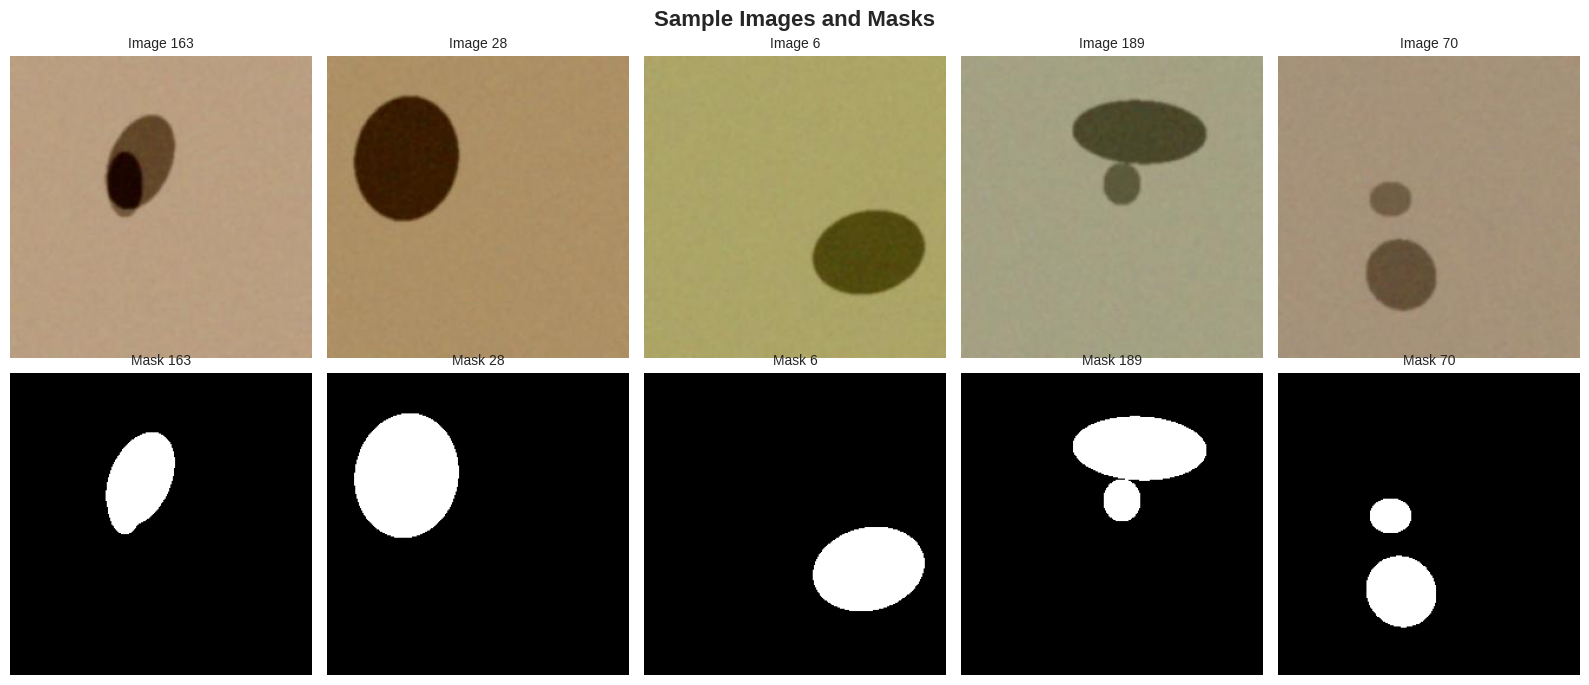


Mask statistics across 200 samples:
  Mean lesion area:     6431 pixels (9.8%)
  Median lesion area:   6399 pixels (9.8%)
  Min lesion area:      2199 pixels (3.4%)
  Max lesion area:      12686 pixels (19.4%)


In [6]:
# ============================================================
# Section 1b: Load and Inspect Sample Images
# ============================================================
# Load a few images and masks to verify structure

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Sample Images and Masks", fontsize=16, fontweight="bold")

sample_indices = random.sample(range(len(image_files)), 5)

for col, idx in enumerate(sample_indices):
    img = np.array(Image.open(os.path.join(DATA_DIR, "images", image_files[idx])))
    msk = np.array(Image.open(os.path.join(DATA_DIR, "masks", mask_files[idx])))

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Image {idx}", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(msk, cmap="gray")
    axes[1, col].set_title(f"Mask {idx}", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Dermoscopy", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Ground Truth", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Compute mask statistics
areas = []
for mf in mask_files:
    m = np.array(Image.open(os.path.join(DATA_DIR, "masks", mf)))
    areas.append((m > 127).sum())

total_pixels = IMG_SIZE * IMG_SIZE
print(f"\nMask statistics across {len(mask_files)} samples:")
print(f"  Mean lesion area:     {np.mean(areas):.0f} pixels ({np.mean(areas)/total_pixels*100:.1f}%)")
print(f"  Median lesion area:   {np.median(areas):.0f} pixels ({np.median(areas)/total_pixels*100:.1f}%)")
print(f"  Min lesion area:      {np.min(areas):.0f} pixels ({np.min(areas)/total_pixels*100:.1f}%)")
print(f"  Max lesion area:      {np.max(areas):.0f} pixels ({np.max(areas)/total_pixels*100:.1f}%)")


## 2. Visualize Masks and Overlays

Before training, we need to understand the data visually. For segmentation,
the critical visualization is the **overlay** -- the predicted or ground-truth
mask superimposed on the original image with transparency.

This is exactly what a clinician would see: the original image with the AI's
predicted boundary drawn on top. Does the boundary follow the lesion edge?
Does it over-segment (too much) or under-segment (too little)?

**Three views for every segmentation sample:**
1. Original image (what the model sees)
2. Ground truth mask (the expert annotation)
3. Overlay (mask on image -- verifies alignment)

> **Corresponds to Lab 1, Slide S35**


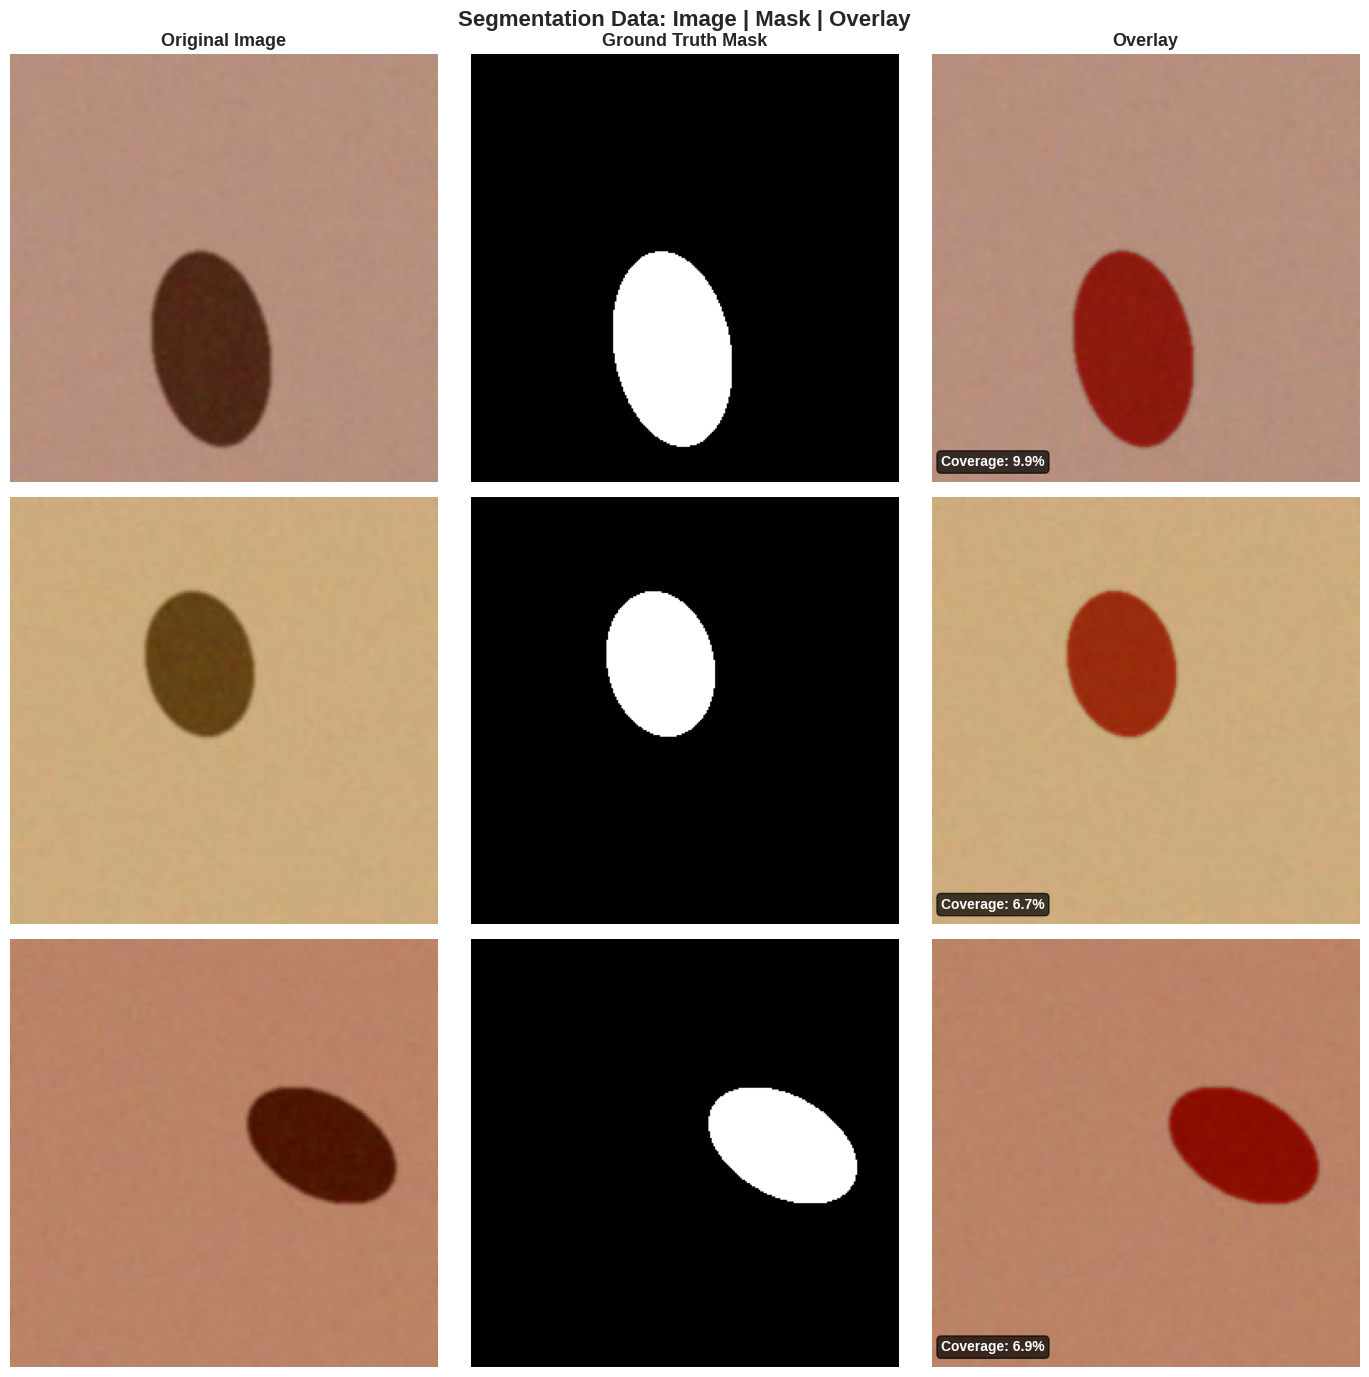

The red overlay shows the ground truth lesion boundary.
In clinical practice, this is what the AI prediction looks like to the doctor.
Accurate boundaries drive accurate measurements (area, diameter, volume).


In [7]:
# ============================================================
# Section 2a: Plot 3x3 Grid — Original | Mask | Overlay
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Segmentation Data: Image | Mask | Overlay", fontsize=16, fontweight="bold")

col_titles = ["Original Image", "Ground Truth Mask", "Overlay"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

sample_indices = random.sample(range(len(image_files)), 3)

for row, idx in enumerate(sample_indices):
    img = np.array(Image.open(os.path.join(DATA_DIR, "images", image_files[idx])))
    msk = np.array(Image.open(os.path.join(DATA_DIR, "masks", mask_files[idx])))
    msk_binary = (msk > 127).astype(np.float32)

    # Original image
    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(f"Sample {idx}", fontsize=11, fontweight="bold")

    # Mask
    axes[row, 1].imshow(msk_binary, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].axis("off")

    # Overlay: image + semi-transparent red mask
    overlay = img.copy().astype(np.float32)
    red_mask = np.zeros_like(overlay)
    red_mask[:, :, 0] = 255  # Red channel
    alpha = 0.35
    lesion_pixels = msk_binary > 0.5
    overlay[lesion_pixels] = (1 - alpha) * overlay[lesion_pixels] + alpha * red_mask[lesion_pixels]
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

    # Compute coverage
    coverage = msk_binary.sum() / msk_binary.size * 100
    axes[row, 2].text(5, IMG_SIZE - 10, f"Coverage: {coverage:.1f}%",
                       fontsize=10, color="white", fontweight="bold",
                       bbox=dict(boxstyle="round", facecolor="black", alpha=0.7))

plt.tight_layout()
plt.show()

print("The red overlay shows the ground truth lesion boundary.")
print("In clinical practice, this is what the AI prediction looks like to the doctor.")
print("Accurate boundaries drive accurate measurements (area, diameter, volume).")


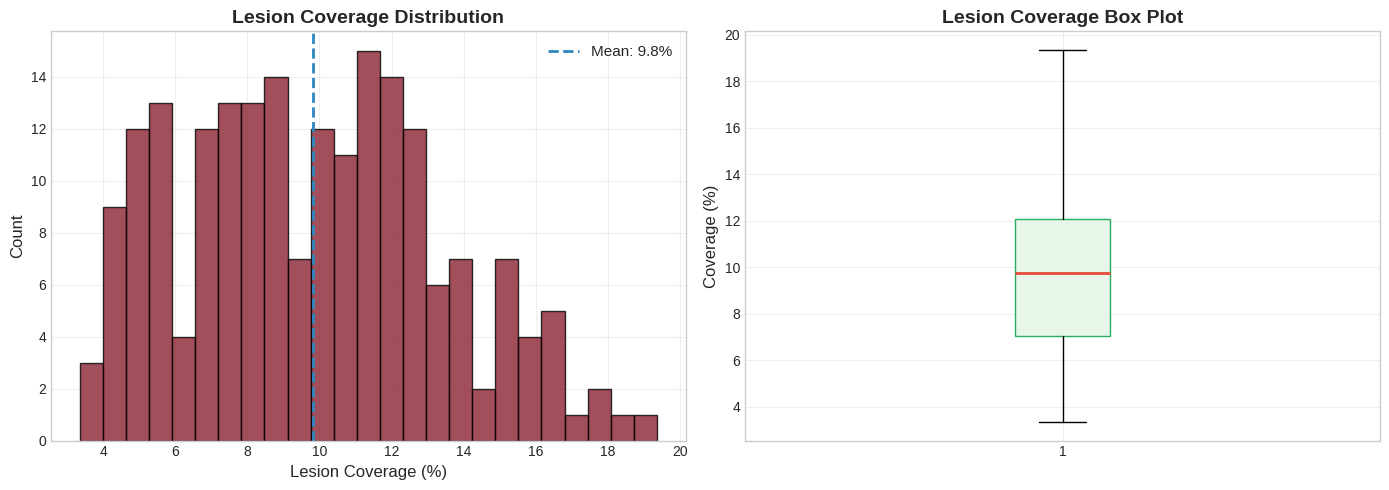

Class imbalance: lesion pixels are the MINORITY class.
Mean coverage: 9.8% -- most of the image is background.
This imbalance is why we need Dice loss instead of just cross-entropy.
Standard BCE treats each pixel equally -- Dice measures region overlap.


In [8]:
# ============================================================
# Section 2b: Mask Area Distribution Histogram
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of lesion areas
coverage_pcts = [a / (IMG_SIZE * IMG_SIZE) * 100 for a in areas]

axes[0].hist(coverage_pcts, bins=25, color="#8B2332", edgecolor="black", alpha=0.8)
axes[0].set_title("Lesion Coverage Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Lesion Coverage (%)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].axvline(np.mean(coverage_pcts), color="#2E86C1", linestyle="--",
                linewidth=2, label=f"Mean: {np.mean(coverage_pcts):.1f}%")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(coverage_pcts, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#E8F5E9", color="#27AE60"),
                medianprops=dict(color="#E74C3C", linewidth=2))
axes[1].set_title("Lesion Coverage Box Plot", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Coverage (%)", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Class imbalance: lesion pixels are the MINORITY class.")
print(f"Mean coverage: {np.mean(coverage_pcts):.1f}% -- most of the image is background.")
print(f"This imbalance is why we need Dice loss instead of just cross-entropy.")
print(f"Standard BCE treats each pixel equally -- Dice measures region overlap.")


## 3. Preprocess and Augment

For segmentation, augmentation is critical but comes with a rule:
**the same transform must be applied to BOTH the image AND the mask.**

If you flip the image horizontally, you must flip the mask too. If you
rotate the image 15 degrees, the mask rotates 15 degrees. Otherwise the
mask no longer aligns with the image -- and your model learns garbage.

**albumentations** handles this automatically: define one pipeline,
pass both image and mask, and both get the same random transform.

**Augmentation pipeline for dermoscopy:**
- HorizontalFlip, VerticalFlip (skin lesions have no canonical orientation)
- RandomBrightnessContrast (simulates different lighting/camera settings)
- ElasticTransform (simulates tissue deformation)
- ShiftScaleRotate (simulates patient positioning variation)
- Resize to 256x256 + Normalize (ImageNet stats for pretrained encoder)

> **Corresponds to Lab 1, Slide S36**


In [9]:
# ============================================================
# Section 3a: Define Augmentation Pipelines
# ============================================================
# Training: augment + preprocess
# Validation/Test: preprocess only

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_augmentation = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ElasticTransform(alpha=80, sigma=80 * 0.05, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_augmentation = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Augmentation pipelines defined:")
print("\nTraining pipeline:")
print("  1. Resize(256, 256)")
print("  2. HorizontalFlip(p=0.5)")
print("  3. VerticalFlip(p=0.5)")
print("  4. ShiftScaleRotate(shift=0.1, scale=0.15, rotate=15)")
print("  5. RandomBrightnessContrast(brightness=0.2, contrast=0.2)")
print("  6. ElasticTransform(alpha=80)")
print("  7. Normalize(ImageNet mean, std)")
print("  8. ToTensorV2()")
print("\nValidation/Test pipeline:")
print("  1. Resize(256, 256)")
print("  2. Normalize(ImageNet mean, std)")
print("  3. ToTensorV2()")
print("\nKey: albumentations applies the SAME random transform to image AND mask.")


Augmentation pipelines defined:

Training pipeline:
  1. Resize(256, 256)
  2. HorizontalFlip(p=0.5)
  3. VerticalFlip(p=0.5)
  4. ShiftScaleRotate(shift=0.1, scale=0.15, rotate=15)
  5. RandomBrightnessContrast(brightness=0.2, contrast=0.2)
  6. ElasticTransform(alpha=80)
  7. Normalize(ImageNet mean, std)
  8. ToTensorV2()

Validation/Test pipeline:
  1. Resize(256, 256)
  2. Normalize(ImageNet mean, std)
  3. ToTensorV2()

Key: albumentations applies the SAME random transform to image AND mask.


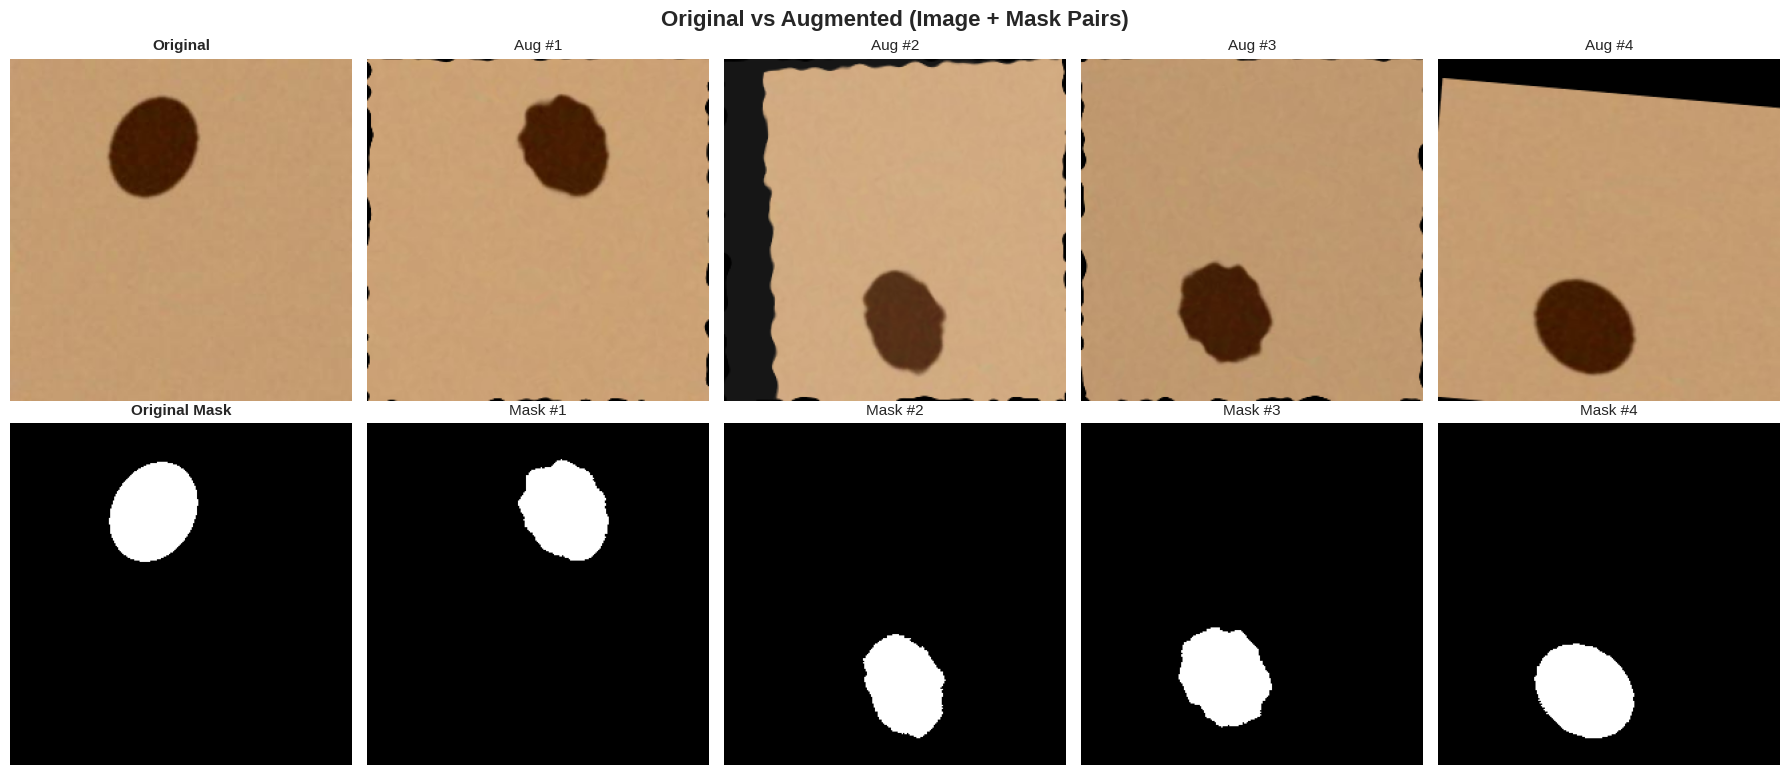

Notice: the SAME random flip/rotation/scale applies to both image and mask.
This is critical: a misaligned mask teaches the model wrong boundaries.
albumentations handles this automatically via A.Compose.


In [10]:
# ============================================================
# Section 3b: Visualize Augmented Examples
# ============================================================
# Show original vs 4 augmented versions (image + mask pairs)

# Use a display-only augmentation (no normalization) for visualization
display_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
    A.ElasticTransform(alpha=80, sigma=80 * 0.05, p=0.5),
])

sample_img = np.array(Image.open(os.path.join(DATA_DIR, "images", image_files[0])))
sample_msk = np.array(Image.open(os.path.join(DATA_DIR, "masks", mask_files[0])))

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Original vs Augmented (Image + Mask Pairs)", fontsize=16, fontweight="bold")

# Original
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title("Original", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")
axes[1, 0].imshow(sample_msk, cmap="gray")
axes[1, 0].set_title("Original Mask", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

# 4 augmented versions
for col in range(1, 5):
    augmented = display_aug(image=sample_img, mask=sample_msk)
    axes[0, col].imshow(augmented["image"])
    axes[0, col].set_title(f"Aug #{col}", fontsize=11)
    axes[0, col].axis("off")
    axes[1, col].imshow(augmented["mask"], cmap="gray")
    axes[1, col].set_title(f"Mask #{col}", fontsize=11)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Mask", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("Notice: the SAME random flip/rotation/scale applies to both image and mask.")
print("This is critical: a misaligned mask teaches the model wrong boundaries.")
print("albumentations handles this automatically via A.Compose.")


## 4. Build U-Net with segmentation_models_pytorch

**segmentation_models_pytorch (SMP)** provides production-ready segmentation
architectures with one line of code. The key insight: the U-Net encoder is
just a classification CNN (the ResNet from Week 8) with the classifier head
removed. SMP handles this automatically.

**U-Net architecture recap:**
- **Encoder** (left side of the U): Compresses image into features -- WHAT is there
- **Decoder** (right side of the U): Expands features back to full resolution -- WHERE it is
- **Skip connections** (horizontal bridges): Pass fine details from encoder to decoder

**Our configuration:**
- `encoder_name="resnet34"`: ResNet-34 backbone (same family as Week 8)
- `encoder_weights="imagenet"`: Transfer learning from ImageNet
- `classes=1`: Binary segmentation (lesion vs background)
- `activation="sigmoid"`: Output probabilities [0, 1] per pixel

> **Corresponds to Lab 2, Slide S54**


In [11]:
# ============================================================
# Section 4a: Create U-Net Model via SMP
# ============================================================
model = smp.Unet(
    encoder_name="resnet34",        # Encoder: ResNet-34 (from Week 8)
    encoder_weights="imagenet",     # Transfer learning from ImageNet
    in_channels=3,                  # RGB input
    classes=1,                      # Binary: lesion vs background
    activation="sigmoid",          # Output: probability per pixel [0, 1]
)
model = model.to(device)

# Model statistics
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f"Model: U-Net with ResNet-34 Encoder")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Encoder parameters:   {encoder_params:,} (pretrained on ImageNet)")
print(f"  Decoder parameters:   {decoder_params:,} (trained from scratch)")
print(f"\n  Input:  3-channel RGB image ({IMG_SIZE}x{IMG_SIZE})")
print(f"  Output: 1-channel probability map ({IMG_SIZE}x{IMG_SIZE})")
print(f"\n  The encoder IS the CNN from Week 8 -- same ResNet features,")
print(f"  now paired with a decoder to produce pixel-level predictions.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model: U-Net with ResNet-34 Encoder
  Total parameters:     24,436,369
  Trainable parameters: 24,436,369
  Encoder parameters:   21,284,672 (pretrained on ImageNet)
  Decoder parameters:   3,151,552 (trained from scratch)

  Input:  3-channel RGB image (256x256)
  Output: 1-channel probability map (256x256)

  The encoder IS the CNN from Week 8 -- same ResNet features,
  now paired with a decoder to produce pixel-level predictions.


In [12]:
# ============================================================
# Section 4b: Create PyTorch Dataset Class
# ============================================================
class SkinDataset(Dataset):
    """PyTorch Dataset for skin lesion segmentation.

    Loads paired image + mask files, applies augmentation,
    and returns tensors ready for U-Net training.
    """
    def __init__(self, image_paths, mask_paths, augmentation=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.augmentation = augmentation

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        # Binarize mask: 0 or 1
        mask = (mask > 127).astype(np.float32)

        # Apply augmentation (same transform to image AND mask)
        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Ensure mask has channel dimension: (1, H, W)
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        else:
            mask = mask.unsqueeze(0).float()

        return image, mask

print("SkinDataset class defined.")
print("Features:")
print("  - Loads paired image + mask")
print("  - Binarizes mask to 0/1")
print("  - Applies identical augmentation to both")
print("  - Returns (image_tensor, mask_tensor) ready for U-Net")


SkinDataset class defined.
Features:
  - Loads paired image + mask
  - Binarizes mask to 0/1
  - Applies identical augmentation to both
  - Returns (image_tensor, mask_tensor) ready for U-Net


In [13]:
# ============================================================
# Section 4c: Create Train/Val/Test Splits and DataLoaders
# ============================================================
# Split: 70% train, 15% val, 15% test
image_paths = sorted([os.path.join(DATA_DIR, "images", f) for f in image_files])
mask_paths = sorted([os.path.join(DATA_DIR, "masks", f) for f in mask_files])

# First split: 70% train, 30% remaining
train_imgs, remaining_imgs, train_masks, remaining_masks = train_test_split(
    image_paths, mask_paths, test_size=0.3, random_state=SEED
)
# Second split: 50/50 of remaining = 15% val, 15% test
val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    remaining_imgs, remaining_masks, test_size=0.5, random_state=SEED
)

# Create datasets
train_dataset = SkinDataset(train_imgs, train_masks, augmentation=train_augmentation)
val_dataset = SkinDataset(val_imgs, val_masks, augmentation=val_augmentation)
test_dataset = SkinDataset(test_imgs, test_masks, augmentation=val_augmentation)

# Create dataloaders
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Dataset splits:")
print(f"  Train:      {len(train_dataset)} images ({len(train_dataset)/N_SAMPLES*100:.0f}%)")
print(f"  Validation: {len(val_dataset)} images ({len(val_dataset)/N_SAMPLES*100:.0f}%)")
print(f"  Test:       {len(test_dataset)} images ({len(test_dataset)/N_SAMPLES*100:.0f}%)")
print(f"\nDataLoaders:")
print(f"  Train:  {len(train_loader)} batches x {BATCH_SIZE}")
print(f"  Val:    {len(val_loader)} batches x {BATCH_SIZE}")
print(f"  Test:   {len(test_loader)} batches x {BATCH_SIZE}")

# Verify a batch
sample_batch_img, sample_batch_mask = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Images: {sample_batch_img.shape}  (batch, channels, H, W)")
print(f"  Masks:  {sample_batch_mask.shape}  (batch, 1, H, W)")
print(f"  Mask range: [{sample_batch_mask.min():.1f}, {sample_batch_mask.max():.1f}]")


Dataset splits:
  Train:      140 images (70%)
  Validation: 30 images (15%)
  Test:       30 images (15%)

DataLoaders:
  Train:  18 batches x 8
  Val:    4 batches x 8
  Test:   4 batches x 8

Batch shapes:
  Images: torch.Size([8, 3, 256, 256])  (batch, channels, H, W)
  Masks:  torch.Size([8, 1, 256, 256])  (batch, 1, H, W)
  Mask range: [0.0, 1.0]


## 5. Train with Dice + BCE Combined Loss

**Why combined loss?**
- **BCE (Binary Cross-Entropy)**: Treats each pixel independently -- good for pixel-level accuracy
- **Dice Loss**: Measures region overlap -- directly optimizes the metric we report
- **Combined**: BCE handles pixel accuracy, Dice handles region overlap

**Dice Score** = 2 * |Intersection| / (|Predicted| + |Ground Truth|)
**Dice Loss** = 1 - Dice Score

**Clinical analogy**: BCE is like grading each question on an exam independently.
Dice is like evaluating the overall answer quality. Combined gives you both
granular feedback AND holistic assessment.

**Training plan:**
- Optimizer: Adam (lr=1e-4)
- Loss: DiceBCELoss (equal weighting)
- Epochs: 20
- Track: train Dice, val Dice per epoch

> **Corresponds to Lab 2, Slides S55-S56**


In [14]:
# ============================================================
# Section 5a: Define DiceBCELoss
# ============================================================
class DiceBCELoss(nn.Module):
    """Combined Dice + Binary Cross-Entropy Loss.

    Dice handles region overlap (good for imbalanced masks).
    BCE handles pixel-level accuracy.
    Together they outperform either alone.
    """
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        # BCE component
        bce_loss = self.bce(pred, target)

        # Dice component
        smooth = 1e-6
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_score = (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        dice_loss = 1.0 - dice_score

        # Combined
        return bce_loss + dice_loss

criterion = DiceBCELoss()
print("DiceBCELoss defined:")
print("  Loss = BCE(pred, target) + (1 - Dice(pred, target))")
print("  BCE handles pixel accuracy, Dice handles region overlap.")
print("  Combined loss outperforms either alone for segmentation.")


DiceBCELoss defined:
  Loss = BCE(pred, target) + (1 - Dice(pred, target))
  BCE handles pixel accuracy, Dice handles region overlap.
  Combined loss outperforms either alone for segmentation.


In [15]:
# ============================================================
# Section 5b: Define Dice Metric Function
# ============================================================
def dice_score(pred, target, threshold=0.5):
    """Compute Dice score between predicted and target masks.

    Args:
        pred: predicted probabilities (B, 1, H, W)
        target: ground truth binary masks (B, 1, H, W)
        threshold: binarization threshold for predictions

    Returns:
        Mean Dice score across the batch
    """
    pred_binary = (pred > threshold).float()
    smooth = 1e-6
    pred_flat = pred_binary.view(pred.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred_flat.sum(dim=1) + target_flat.sum(dim=1) + smooth)
    return dice.mean().item()


def iou_score(pred, target, threshold=0.5):
    """Compute Intersection over Union (IoU / Jaccard index).

    Args:
        pred: predicted probabilities (B, 1, H, W)
        target: ground truth binary masks (B, 1, H, W)
        threshold: binarization threshold

    Returns:
        Mean IoU across the batch
    """
    pred_binary = (pred > threshold).float()
    smooth = 1e-6
    pred_flat = pred_binary.view(pred.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(dim=1)
    union = pred_flat.sum(dim=1) + target_flat.sum(dim=1) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()


print("Metric functions defined:")
print("  dice_score(pred, target) -- 2*|A and B| / (|A| + |B|)")
print("  iou_score(pred, target)  -- |A and B| / |A or B|)")
print("\nDice = 1.0 means perfect overlap. Dice = 0.0 means no overlap.")
print("IoU is always <= Dice for the same prediction.")


Metric functions defined:
  dice_score(pred, target) -- 2*|A and B| / (|A| + |B|)
  iou_score(pred, target)  -- |A and B| / |A or B|)

Dice = 1.0 means perfect overlap. Dice = 0.0 means no overlap.
IoU is always <= Dice for the same prediction.


In [ ]:
# ============================================================
# Section 5c: Training Loop
# ============================================================
NUM_EPOCHS = 20
LR = 1e-4

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

history = {
    "train_loss": [], "train_dice": [],
    "val_loss": [], "val_dice": [],
}

best_val_dice = 0.0
best_model_state = None

print(f"Training U-Net for skin lesion segmentation")
print(f"{'='*65}")
print(f"  Encoder:    ResNet-34 (ImageNet pretrained)")
print(f"  Loss:       DiceBCE (Dice + Binary Cross-Entropy)")
print(f"  Optimizer:  Adam (lr={LR})")
print(f"  Scheduler:  ReduceLROnPlateau (patience=5)")
print(f"  Epochs:     {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Device:     {device}")
print()

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    train_loss_sum = 0.0
    train_dice_sum = 0.0
    train_batches = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_dice_sum += dice_score(preds.detach(), masks)
        train_batches += 1

    avg_train_loss = train_loss_sum / train_batches
    avg_train_dice = train_dice_sum / train_batches

    # --- Validation phase ---
    model.eval()
    val_loss_sum = 0.0
    val_dice_sum = 0.0
    val_batches = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            preds = model(images)
            loss = criterion(preds, masks)

            val_loss_sum += loss.item()
            val_dice_sum += dice_score(preds, masks)
            val_batches += 1

    avg_val_loss = val_loss_sum / val_batches
    avg_val_dice = val_dice_sum / val_batches

    # Update scheduler
    scheduler.step(avg_val_dice)

    # Save best model
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        best_model_state = copy.deepcopy(model.state_dict())

    # Record history
    history["train_loss"].append(avg_train_loss)
    history["train_dice"].append(avg_train_dice)
    history["val_loss"].append(avg_val_loss)
    history["val_dice"].append(avg_val_dice)

    elapsed = time.time() - start_time
    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} Dice: {avg_train_dice:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} Dice: {avg_val_dice:.4f} | "
          f"Time: {elapsed:.1f}s")

# Load best model
model.load_state_dict(best_model_state)
total_time = time.time() - start_time
print(f"\nTraining complete in {total_time:.1f}s")
print(f"Best validation Dice: {best_val_dice:.4f}")


Training U-Net for skin lesion segmentation
  Encoder:    ResNet-34 (ImageNet pretrained)
  Loss:       DiceBCE (Dice + Binary Cross-Entropy)
  Optimizer:  Adam (lr=0.0001)
  Scheduler:  ReduceLROnPlateau (patience=5)
  Epochs:     20
  Batch size: 8
  Device:     cpu

  Epoch  1/20 | Train Loss: 1.3590 Dice: 0.4023 | Val Loss: 1.7511 Dice: 0.4363 | Time: 190.8s
  Epoch  2/20 | Train Loss: 1.0920 Dice: 0.6400 | Val Loss: 1.0573 Dice: 0.6696 | Time: 373.5s
  Epoch  3/20 | Train Loss: 1.0116 Dice: 0.7394 | Val Loss: 0.9012 Dice: 0.8860 | Time: 553.8s
  Epoch  4/20 | Train Loss: 0.9606 Dice: 0.8226 | Val Loss: 0.8620 Dice: 0.9202 | Time: 741.3s
  Epoch  5/20 | Train Loss: 0.9160 Dice: 0.8839 | Val Loss: 0.8226 Dice: 0.9565 | Time: 922.3s
  Epoch  6/20 | Train Loss: 0.8802 Dice: 0.9235 | Val Loss: 0.7888 Dice: 0.9749 | Time: 1100.7s
  Epoch  7/20 | Train Loss: 0.8425 Dice: 0.9428 | Val Loss: 0.7627 Dice: 0.9666 | Time: 1279.2s
  Epoch  8/20 | Train Loss: 0.8025 Dice: 0.9578 | Val Loss: 0.7

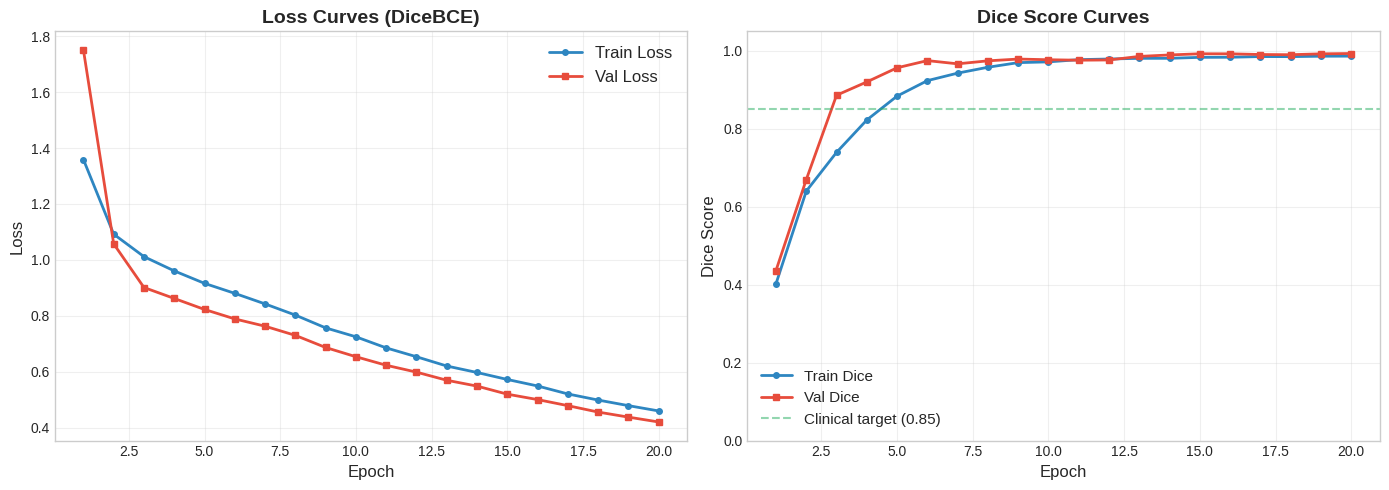

Interpretation:
  - Both curves converging: good training
  - Val Dice stalling while Train Dice rises: overfitting
  - Dice > 0.85 is generally considered clinically useful for most tasks

  Final train Dice: 0.9863
  Final val Dice:   0.9931
  Best val Dice:    0.9931


In [ ]:
# ============================================================
# Section 5d: Plot Learning Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curves
axes[0].plot(epochs_range, history["train_loss"], "o-", color="#2E86C1",
             label="Train Loss", linewidth=2, markersize=4)
axes[0].plot(epochs_range, history["val_loss"], "s-", color="#E74C3C",
             label="Val Loss", linewidth=2, markersize=4)
axes[0].set_title("Loss Curves (DiceBCE)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Dice curves
axes[1].plot(epochs_range, history["train_dice"], "o-", color="#2E86C1",
             label="Train Dice", linewidth=2, markersize=4)
axes[1].plot(epochs_range, history["val_dice"], "s-", color="#E74C3C",
             label="Val Dice", linewidth=2, markersize=4)
axes[1].set_title("Dice Score Curves", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Dice Score", fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.0, 1.05])
axes[1].axhline(y=0.85, color="#27AE60", linestyle="--", alpha=0.5, label="Clinical target (0.85)")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Both curves converging: good training")
print("  - Val Dice stalling while Train Dice rises: overfitting")
print("  - Dice > 0.85 is generally considered clinically useful for most tasks")
print(f"\n  Final train Dice: {history['train_dice'][-1]:.4f}")
print(f"  Final val Dice:   {history['val_dice'][-1]:.4f}")
print(f"  Best val Dice:    {best_val_dice:.4f}")


## 6. Evaluate -- Dice, IoU, and Visual Predictions

Now we evaluate the trained U-Net on the **held-out test set** that the model
has never seen during training or validation.

**Evaluation strategy:**
1. **Dice Score**: Primary metric -- measures region overlap (higher is better)
2. **IoU (Jaccard)**: Secondary metric -- always lower than Dice
3. **Visual overlay**: Original image + ground truth + prediction + overlay grid
4. **Failure analysis**: Which samples have the lowest Dice? Why?

**Clinical framing:** A Dice of 0.90 sounds great -- but if the worst-case
prediction has Dice 0.40, there is a patient getting a severely wrong boundary.
In clinical AI, worst-case performance matters as much as average performance.

> **Corresponds to Lab 2, Slides S57-S58**


In [ ]:
# ============================================================
# Section 6a: Compute Test Metrics
# ============================================================
model.eval()

test_dices = []
test_ious = []
all_preds_list = []
all_masks_list = []
all_images_list = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        preds = model(images)

        # Per-sample Dice and IoU
        for i in range(images.size(0)):
            pred_i = preds[i:i+1]
            mask_i = masks[i:i+1]
            d = dice_score(pred_i, mask_i)
            j = iou_score(pred_i, mask_i)
            test_dices.append(d)
            test_ious.append(j)

            # Store for visualization (move to CPU)
            all_preds_list.append(preds[i].cpu())
            all_masks_list.append(masks[i].cpu())
            all_images_list.append(images[i].cpu())

test_dices = np.array(test_dices)
test_ious = np.array(test_ious)

print(f"Test Set Evaluation ({len(test_dices)} images)")
print(f"{'='*50}")
print(f"  Dice Score:")
print(f"    Mean:   {test_dices.mean():.4f}")
print(f"    Std:    {test_dices.std():.4f}")
print(f"    Min:    {test_dices.min():.4f}")
print(f"    Max:    {test_dices.max():.4f}")
print(f"    Median: {np.median(test_dices):.4f}")
print(f"\n  IoU Score:")
print(f"    Mean:   {test_ious.mean():.4f}")
print(f"    Std:    {test_ious.std():.4f}")
print(f"    Min:    {test_ious.min():.4f}")
print(f"    Max:    {test_ious.max():.4f}")

# Clinical interpretation
if test_dices.mean() >= 0.85:
    verdict = "CLINICALLY USEFUL -- above 0.85 threshold"
elif test_dices.mean() >= 0.70:
    verdict = "MODERATE -- useful for screening, not for surgical planning"
else:
    verdict = "NEEDS IMPROVEMENT -- below clinical utility threshold"

print(f"\n  Clinical verdict: {verdict}")


Test Set Evaluation (30 images)
  Dice Score:
    Mean:   0.9934
    Std:    0.0027
    Min:    0.9860
    Max:    0.9969
    Median: 0.9941

  IoU Score:
    Mean:   0.9870
    Std:    0.0053
    Min:    0.9723
    Max:    0.9937

  Clinical verdict: CLINICALLY USEFUL -- above 0.85 threshold


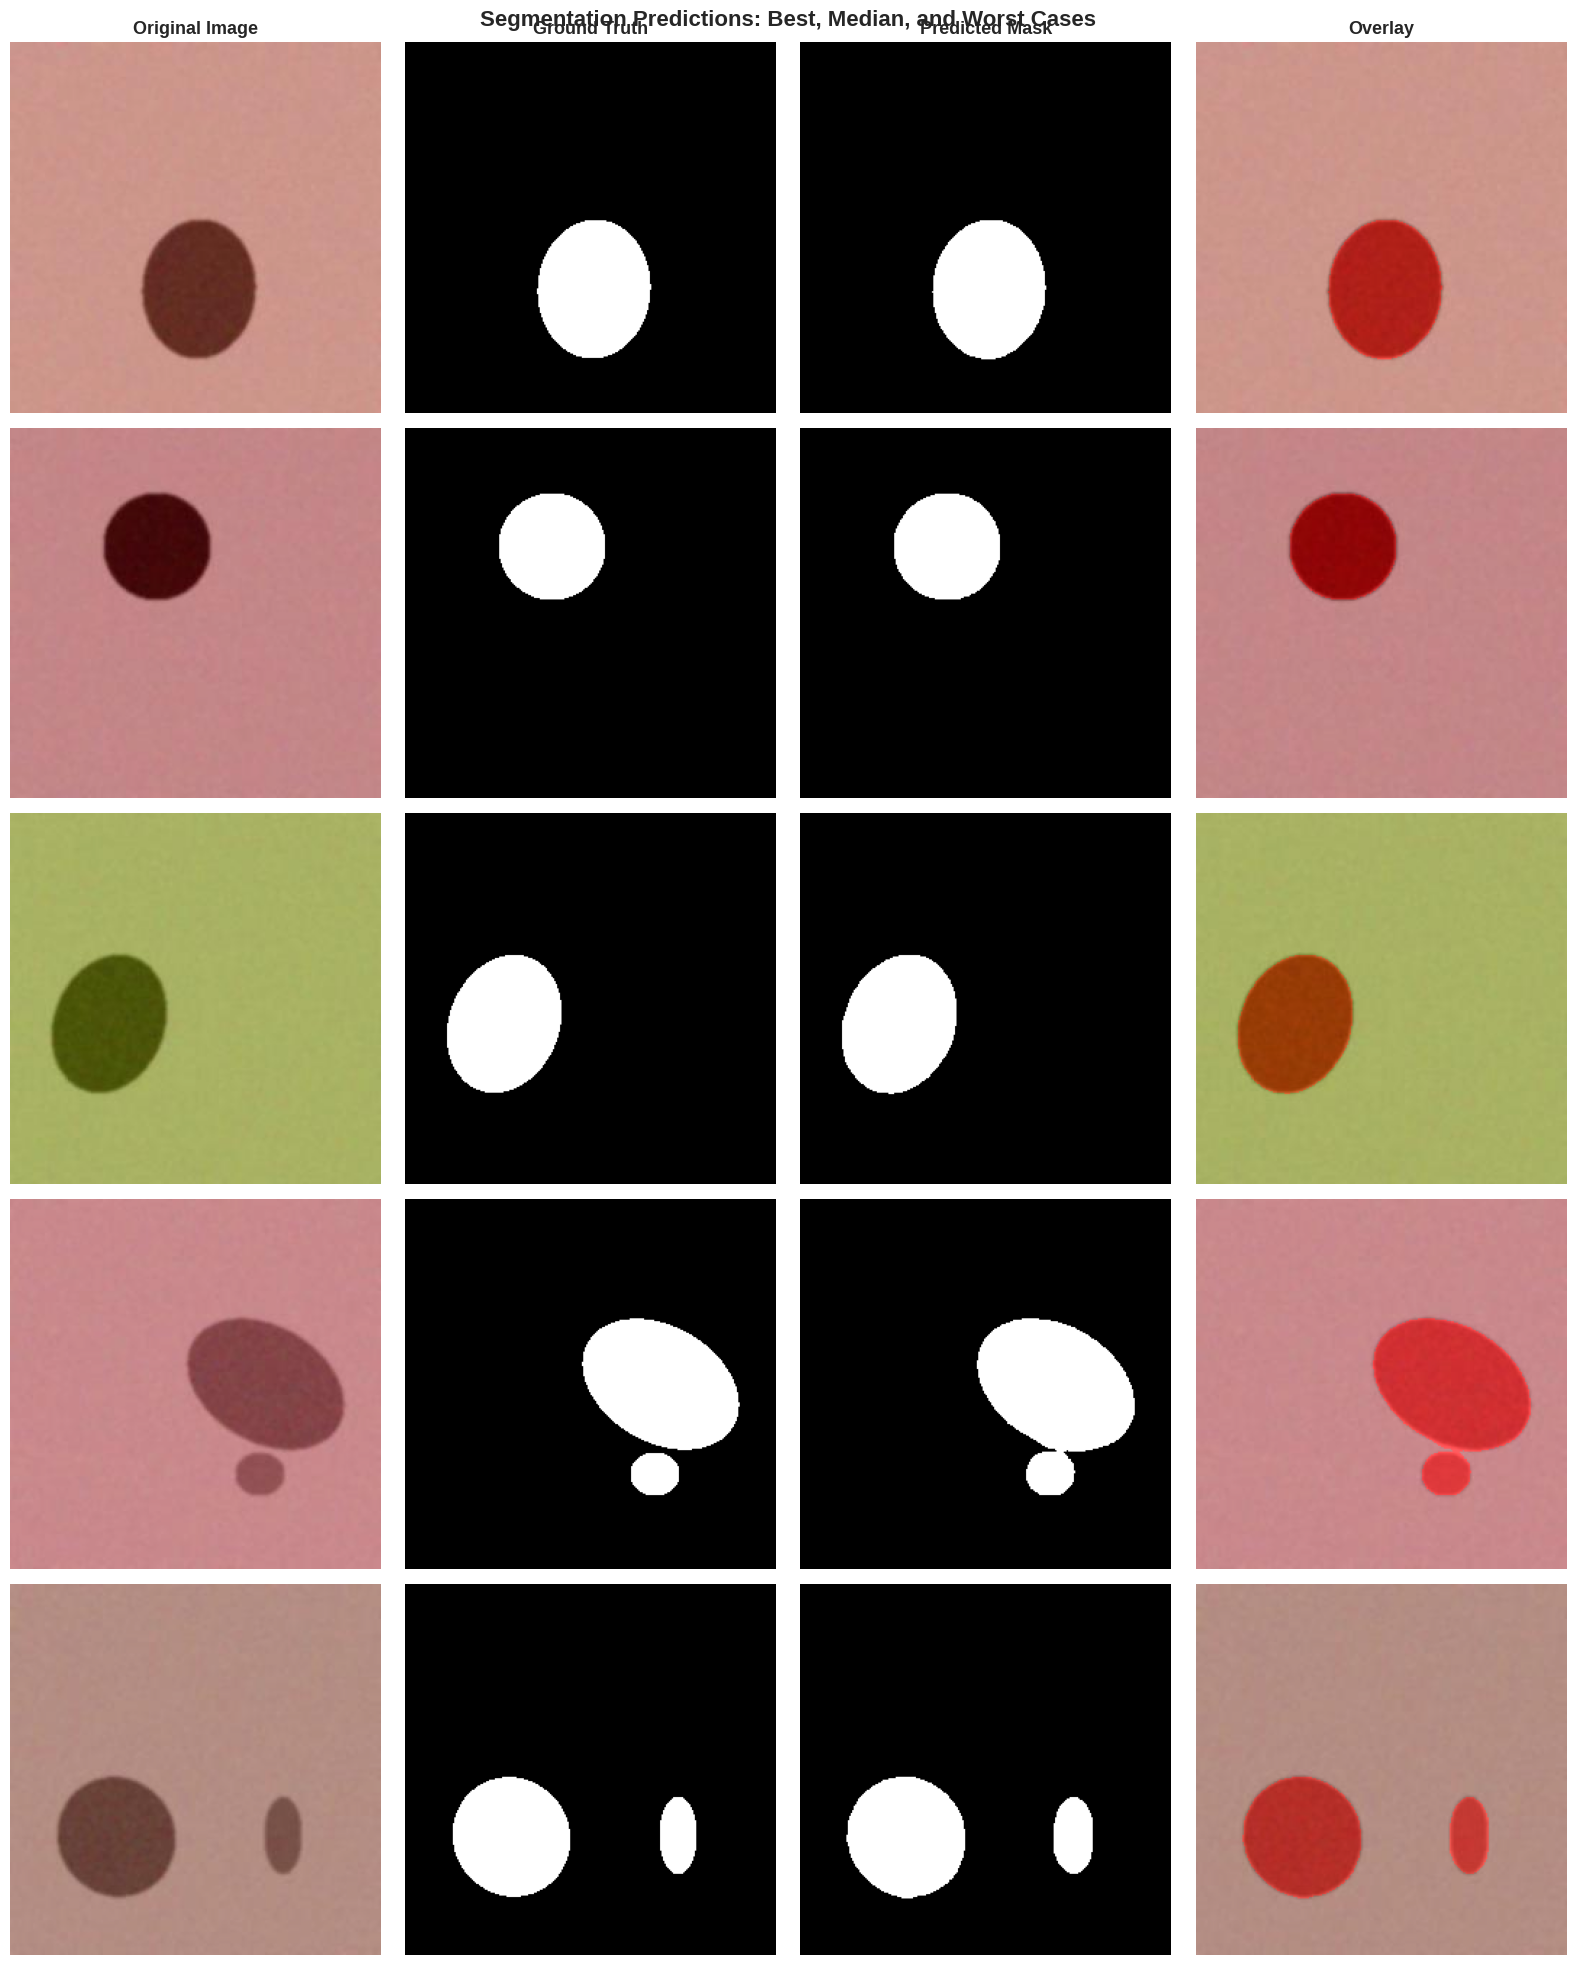

Top rows: best predictions (highest Dice).
Middle row: median prediction.
Bottom rows: worst predictions (lowest Dice).

Failure cases often involve: ambiguous boundaries, very small lesions,
or unusual morphology -- the same cases that challenge human annotators.


In [ ]:
# ============================================================
# Section 6b: Visualize Predictions — Original | GT | Predicted | Overlay
# ============================================================
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for display."""
    img = tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return torch.clamp(img, 0, 1)


# Select best and worst predictions
sorted_indices = np.argsort(test_dices)
worst_indices = sorted_indices[:2]
best_indices = sorted_indices[-2:]
mid_index = sorted_indices[len(sorted_indices) // 2]
show_indices = list(best_indices) + [mid_index] + list(worst_indices)

fig, axes = plt.subplots(len(show_indices), 4, figsize=(16, 4 * len(show_indices)))
fig.suptitle("Segmentation Predictions: Best, Median, and Worst Cases",
             fontsize=16, fontweight="bold")
col_titles = ["Original Image", "Ground Truth", "Predicted Mask", "Overlay"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for row, idx in enumerate(show_indices):
    img = denormalize(all_images_list[idx]).permute(1, 2, 0).numpy()
    gt = all_masks_list[idx].squeeze().numpy()
    pred = (all_preds_list[idx].squeeze().numpy() > 0.5).astype(np.float32)
    d = test_dices[idx]

    # Original
    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    color = "#27AE60" if d >= 0.85 else "#E67E22" if d >= 0.70 else "#E74C3C"
    axes[row, 0].set_ylabel(f"Dice={d:.3f}", fontsize=11, fontweight="bold", color=color)

    # Ground truth
    axes[row, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].axis("off")

    # Predicted mask
    axes[row, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].axis("off")

    # Overlay: image + green GT contour + red prediction contour
    overlay = img.copy()
    # Red for prediction
    pred_mask = pred > 0.5
    overlay_red = overlay.copy()
    overlay_red[pred_mask, 0] = np.clip(overlay_red[pred_mask, 0] + 0.3, 0, 1)
    overlay_red[pred_mask, 1] = overlay_red[pred_mask, 1] * 0.7
    overlay_red[pred_mask, 2] = overlay_red[pred_mask, 2] * 0.7
    axes[row, 3].imshow(overlay_red)
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

print("Top rows: best predictions (highest Dice).")
print("Middle row: median prediction.")
print("Bottom rows: worst predictions (lowest Dice).")
print("\nFailure cases often involve: ambiguous boundaries, very small lesions,")
print("or unusual morphology -- the same cases that challenge human annotators.")


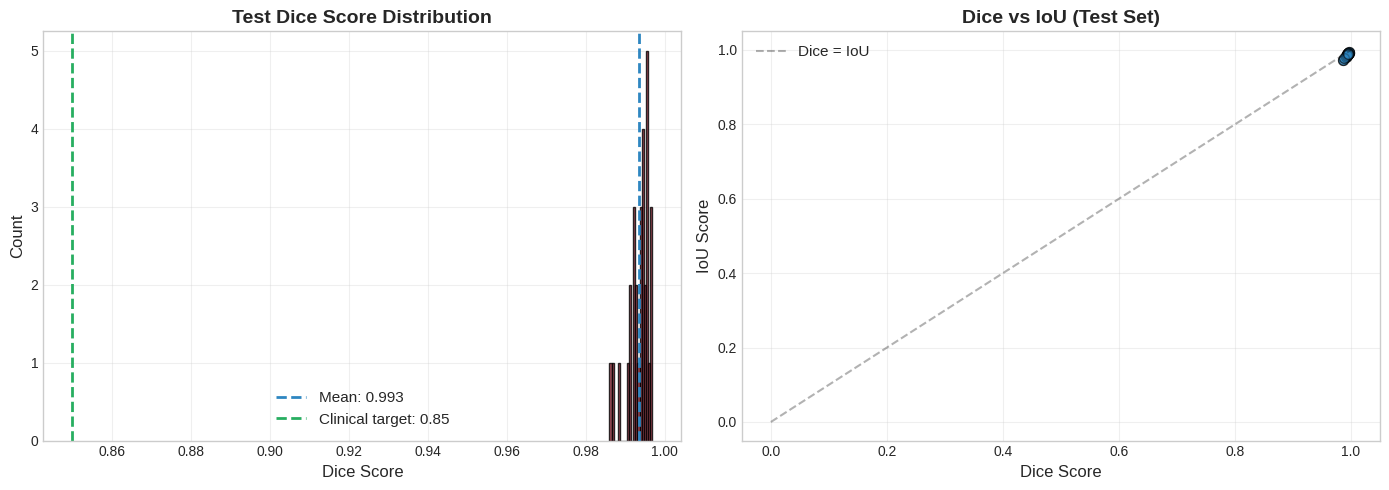

Performance breakdown:
  Dice >= 0.85 (clinical quality): 30/30 (100.0%)
  Dice >= 0.70 (moderate):         30/30 (100.0%)
  Dice <  0.70 (needs review):     0/30 (0.0%)

Note: Dice is ALWAYS >= IoU for the same prediction pair.
IoU is a stricter metric -- a Dice of 0.85 corresponds to IoU of ~0.74.


In [ ]:
# ============================================================
# Section 6c: Dice Score Distribution and Failure Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice distribution histogram
axes[0].hist(test_dices, bins=20, color="#8B2332", edgecolor="black", alpha=0.8)
axes[0].axvline(test_dices.mean(), color="#2E86C1", linestyle="--",
                linewidth=2, label=f"Mean: {test_dices.mean():.3f}")
axes[0].axvline(0.85, color="#27AE60", linestyle="--",
                linewidth=2, label="Clinical target: 0.85")
axes[0].set_title("Test Dice Score Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dice Score", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Dice vs IoU scatter
axes[1].scatter(test_dices, test_ious, color="#2E86C1", alpha=0.6, edgecolors="black", s=50)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Dice = IoU")
axes[1].set_title("Dice vs IoU (Test Set)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Dice Score", fontsize=12)
axes[1].set_ylabel("IoU Score", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

# Count samples above/below thresholds
above_85 = (test_dices >= 0.85).sum()
above_70 = (test_dices >= 0.70).sum()
below_70 = (test_dices < 0.70).sum()
print(f"Performance breakdown:")
print(f"  Dice >= 0.85 (clinical quality): {above_85}/{len(test_dices)} ({above_85/len(test_dices)*100:.1f}%)")
print(f"  Dice >= 0.70 (moderate):         {above_70}/{len(test_dices)} ({above_70/len(test_dices)*100:.1f}%)")
print(f"  Dice <  0.70 (needs review):     {below_70}/{len(test_dices)} ({below_70/len(test_dices)*100:.1f}%)")
print(f"\nNote: Dice is ALWAYS >= IoU for the same prediction pair.")
print(f"IoU is a stricter metric -- a Dice of 0.85 corresponds to IoU of ~0.74.")


## 7. Student Tasks

Complete the following tasks to deepen your understanding of medical image
segmentation. Each task builds on the code above.

| Task | Description | Difficulty |
|------|-------------|------------|
| T1 | Change encoder from ResNet34 to EfficientNet-B0 -- compare Dice and training speed | :star: |
| T2 | Implement Hausdorff distance metric -- which test images have worst boundary accuracy? | :star: |
| T3 | Use `smp.Unet` with `decoder_attention_type="scse"` for Attention U-Net -- does Dice improve? | :star::star: |
| T4 | Add CRF post-processing to sharpen predicted boundaries -- compare before/after | :star::star: |
| T5 | Extend to 3-class segmentation: background (0), lesion interior (1), lesion border (2) | :star::star::star: |

> **Corresponds to Lab 2, Slide S59**


In [ ]:
# ============================================================
# Task 1 (Star): Change Encoder to EfficientNet-B0
# ============================================================
# Compare: (a) Dice score, (b) training time, (c) model size
#
# Hint:
#   model_eff = smp.Unet(
#       encoder_name="efficientnet-b0",
#       encoder_weights="imagenet",
#       classes=1,
#       activation="sigmoid",
#   ).to(device)
#
#   eff_params = sum(p.numel() for p in model_eff.parameters())
#   print(f"EfficientNet-B0 U-Net: {eff_params:,} parameters")
#
#   # Train with the same DiceBCELoss, Adam, and 20 epochs
#   # Compare final val Dice and training time with ResNet34 U-Net
#
# Expected: EfficientNet-B0 has fewer parameters but may achieve
# similar or slightly different Dice due to different feature patterns.

# YOUR CODE HERE:



In [ ]:
# ============================================================
# Task 2 (Star): Implement Hausdorff Distance
# ============================================================
# Hausdorff distance measures the MAXIMUM boundary error.
# A Dice of 0.90 with Hausdorff of 15mm means one boundary
# point is 15mm off -- critical for surgical margins.
#
# Hint:
#   from scipy.ndimage import distance_transform_edt
#
#   def hausdorff_distance(pred_mask, gt_mask):
#       """Compute Hausdorff distance between two binary masks."""
#       # Find boundary pixels
#       from scipy.ndimage import binary_erosion
#       pred_boundary = pred_mask ^ binary_erosion(pred_mask)
#       gt_boundary = gt_mask ^ binary_erosion(gt_mask)
#
#       if pred_boundary.sum() == 0 or gt_boundary.sum() == 0:
#           return float("inf")
#
#       # Distance transforms
#       dt_pred = distance_transform_edt(~pred_boundary)
#       dt_gt = distance_transform_edt(~gt_boundary)
#
#       # Hausdorff = max(max(dt_pred[gt_boundary]), max(dt_gt[pred_boundary]))
#       d1 = dt_pred[gt_boundary].max()
#       d2 = dt_gt[pred_boundary].max()
#       return max(d1, d2)
#
#   # Compute Hausdorff for all test images
#   # Identify the 5 worst cases -- what do they look like?

# YOUR CODE HERE:



In [ ]:
# ============================================================
# Task 3 (Star-Star): Attention U-Net via SMP
# ============================================================
# Attention gates suppress irrelevant regions and highlight
# target structures -- like a radiologist focusing on the lesion.
#
# Hint:
#   model_attention = smp.Unet(
#       encoder_name="resnet34",
#       encoder_weights="imagenet",
#       classes=1,
#       activation="sigmoid",
#       decoder_attention_type="scse",  # Spatial + Channel SE attention
#   ).to(device)
#
#   # Train with same settings and compare:
#   # 1. Final Dice score
#   # 2. Worst-case Dice (does attention help hard cases?)
#   # 3. Training time difference
#
# Expected: Attention U-Net may improve on difficult cases
# (small lesions, ambiguous borders) where focusing matters most.

# YOUR CODE HERE:



In [ ]:
# ============================================================
# Task 4 (Star-Star): CRF Post-Processing
# ============================================================
# Conditional Random Fields (CRF) refine predicted masks by
# considering pixel spatial relationships and color similarity.
# This sharpens blurry boundaries produced by the neural network.
#
# Hint:
#   # Install: !pip install pydensecrf --quiet
#   import pydensecrf.densecrf as dcrf
#   from pydensecrf.utils import unary_from_softmax
#
#   def apply_crf(image_rgb, pred_prob, n_iters=5):
#       """Refine prediction using Dense CRF."""
#       h, w = pred_prob.shape
#       d = dcrf.DenseCRF2D(w, h, 2)
#
#       # Unary potentials
#       prob_2class = np.stack([1 - pred_prob, pred_prob], axis=0)
#       unary = unary_from_softmax(prob_2class)
#       d.setUnaryEnergy(unary)
#
#       # Pairwise potentials (appearance + smoothness)
#       d.addPairwiseGaussian(sxy=3, compat=3)
#       d.addPairwiseBilateral(
#           sxy=50, srgb=13,
#           rgbim=image_rgb.astype(np.uint8),
#           compat=10,
#       )
#
#       Q = d.inference(n_iters)
#       refined = np.argmax(Q, axis=0).reshape(h, w)
#       return refined
#
#   # Compare Dice before and after CRF for test images

# YOUR CODE HERE:



In [ ]:
# ============================================================
# Task 5 (Star-Star-Star): Multi-Class Segmentation
# ============================================================
# Extend from binary (background/lesion) to 3 classes:
#   0: Background
#   1: Lesion interior
#   2: Lesion border (pixels within 5px of the lesion edge)
#
# This requires changes to:
# 1. Mask generation: add border class using morphological operations
# 2. Model: smp.Unet(..., classes=3, activation="softmax")
# 3. Loss: CrossEntropyLoss instead of BCE (or multi-class Dice)
# 4. Evaluation: per-class Dice scores
#
# Hint for border mask:
#   from scipy.ndimage import binary_dilation, binary_erosion
#
#   def create_3class_mask(binary_mask, border_width=5):
#       dilated = binary_dilation(binary_mask, iterations=border_width)
#       eroded = binary_erosion(binary_mask, iterations=border_width)
#       border = dilated.astype(int) - eroded.astype(int)
#       mask_3class = np.zeros_like(binary_mask, dtype=np.int64)
#       mask_3class[binary_mask > 0] = 1  # Interior
#       mask_3class[border > 0] = 2       # Border
#       return mask_3class
#
# Clinical relevance: the border region is where diagnostic
# uncertainty is highest -- ABCDE border criteria for melanoma.

# YOUR CODE HERE:



## 8. Gemini AI Exercise

Use Google Colab's built-in **Gemini AI** to explore U-Net architecture
decisions, loss function selection, and clinical deployment strategies
for medical image segmentation.

These prompts develop critical thinking about segmentation beyond just
training a model -- understanding WHY architectures work, HOW to improve
failing models, and WHEN to choose specific loss functions.

> **Corresponds to Lab 2, Slide S60**


In [ ]:
# ============================================================
# Section 8a: Gemini Prompt 1 — Skip Connections Explained
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 1: U-Net Skip Connections")
    print("=" * 65)
    response = ai.generate_text(
        "Explain how U-Net skip connections work using a medical "
        "analogy. Why are they essential for segmentation but not "
        "for classification? Keep it under 200 words."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("This section works only in Google Colab.")
    print("\nTry this prompt manually in Colab Gemini sidebar:")
    print("-" * 65)
    print('"Explain how U-Net skip connections work using a medical')
    print("analogy. Why are they essential for segmentation but not")
    print('for classification? Keep it under 200 words."')


Gemini Prompt 1: U-Net Skip Connections


TimeoutException: Requesting secret MODEL_PROXY_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
# ============================================================
# Section 8b: Gemini Prompt 2 — Improving Segmentation
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 2: Improving Segmentation Performance")
    print("=" * 65)
    response = ai.generate_text(
        "I am training a U-Net for skin lesion segmentation with "
        "Dice score 0.78. The model misses small lesions and has "
        "fuzzy boundaries on large ones. Suggest 3 specific "
        "strategies to improve, explaining why each would help."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab Gemini sidebar:")
    print("-" * 65)
    print('"I am training a U-Net for skin lesion segmentation with')
    print("Dice score 0.78. The model misses small lesions and has")
    print("fuzzy boundaries on large ones. Suggest 3 specific")
    print('strategies to improve, explaining why each would help."')


In [ ]:
# ============================================================
# Section 8c: Gemini Prompt 3 — Loss Function Comparison
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 3: Loss Function Selection")
    print("=" * 65)
    response = ai.generate_text(
        "Compare Dice loss, BCE loss, and combined Dice+BCE loss "
        "for medical image segmentation. When would you choose "
        "each? Give a clinical example for each scenario."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab Gemini sidebar:")
    print("-" * 65)
    print('"Compare Dice loss, BCE loss, and combined Dice+BCE loss')
    print("for medical image segmentation. When would you choose")
    print('each? Give a clinical example for each scenario."')

print("\n" + "=" * 65)
print("Key learning: Gemini can serve as a segmentation architecture")
print("consultant. Ask about loss functions, failure analysis, and")
print("deployment strategies -- but always validate with domain experts.")


## 9. Bonus: MedSAM -- Segment Anything in Medicine

**MedSAM** (Ma et al., Nature Communications 2024) is a foundation model
for medical image segmentation. Based on Meta's Segment Anything Model (SAM),
MedSAM was fine-tuned on **1.5 million medical image-mask pairs** across
**10 imaging modalities**.

**How it works:**
1. Give MedSAM an image + a prompt (point click or bounding box)
2. MedSAM outputs a segmentation mask instantly
3. No task-specific training needed -- one model for ANY anatomy

**Why this matters:** Traditional U-Net requires training per task
(skin lesions, cardiac MRI, brain tumors -- each needs its own dataset
and training run). MedSAM is a single model that segments everything.

This demo shows the conceptual MedSAM workflow. For full usage,
see: https://github.com/bowang-lab/MedSAM


In [ ]:
# ============================================================
# Section 9: MedSAM Conceptual Demo
# ============================================================
# NOTE: Full MedSAM requires ~2.4GB model download.
# This cell demonstrates the WORKFLOW conceptually using
# our trained U-Net as a stand-in.
#
# Real MedSAM usage:
#   !pip install git+https://github.com/bowang-lab/MedSAM --quiet
#   from segment_anything import sam_model_registry
#   medsam = sam_model_registry["vit_b"](checkpoint="medsam_vit_b.pth")

print("MedSAM Conceptual Demo")
print("=" * 65)
print()
print("MedSAM Architecture:")
print("  1. Image Encoder: ViT-B (Vision Transformer)")
print("  2. Prompt Encoder: processes point/box/mask prompts")
print("  3. Mask Decoder: lightweight decoder producing segmentation")
print()
print("Training data: 1.5M image-mask pairs across 10 modalities:")
print("  CT, MRI, X-ray, Ultrasound, Endoscopy, Dermoscopy,")
print("  Fundoscopy, Microscopy, Mammography, OCT")
print()
print("Key advantage over task-specific U-Net:")
print("  U-Net: train on 200 skin images -> works for skin only")
print("  MedSAM: pre-trained on 1.5M images -> works for ANY anatomy")
print("  Just give a point prompt or bounding box -> instant mask")
print()

# Simulate MedSAM-like interactive segmentation with our model
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle("MedSAM-Style Workflow: Point Prompt -> Segmentation",
             fontsize=14, fontweight="bold")

# Pick a test sample
sample_idx = 0
img_display = denormalize(all_images_list[sample_idx]).permute(1, 2, 0).numpy()
gt_mask = all_masks_list[sample_idx].squeeze().numpy()
pred_mask = (all_preds_list[sample_idx].squeeze().numpy() > 0.5).astype(np.float32)

# Find center of lesion for simulated point prompt
ys, xs = np.where(gt_mask > 0.5)
if len(ys) > 0:
    center_y, center_x = int(ys.mean()), int(xs.mean())
else:
    center_y, center_x = IMG_SIZE // 2, IMG_SIZE // 2

# Step 1: Original image
axes[0].imshow(img_display)
axes[0].set_title("1. Input Image", fontsize=12, fontweight="bold")
axes[0].axis("off")

# Step 2: User places point prompt
axes[1].imshow(img_display)
axes[1].plot(center_x, center_y, "r*", markersize=20, markeredgecolor="white", markeredgewidth=1.5)
axes[1].set_title("2. Point Prompt (click)", fontsize=12, fontweight="bold")
axes[1].axis("off")

# Step 3: MedSAM produces mask (simulated with our U-Net prediction)
axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("3. MedSAM Output", fontsize=12, fontweight="bold")
axes[2].axis("off")

# Step 4: Overlay
overlay = img_display.copy()
green_mask = np.zeros_like(overlay)
green_mask[:, :, 1] = 1.0
lesion = pred_mask > 0.5
overlay[lesion] = 0.6 * overlay[lesion] + 0.4 * green_mask[lesion]
axes[3].imshow(overlay)
axes[3].plot(center_x, center_y, "r*", markersize=15, markeredgecolor="white", markeredgewidth=1)
axes[3].set_title("4. Overlay Result", fontsize=12, fontweight="bold")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("In real MedSAM: one click -> instant segmentation on any anatomy.")
print("No training needed per task -- the foundation model generalizes.")
print("This is the future of interactive medical image annotation.")


## 10. Summary and Self-Check

### Key Takeaways (Matching Slides S73-S74)

1. **Segmentation = classification at the pixel level**: Instead of one label per image (Week 8), we assign a label to EVERY pixel. This enables boundary detection, area measurement, and volume computation that classification cannot provide.

2. **U-Net encoder-decoder with skip connections**: The encoder (ResNet-34 from Week 8) extracts WHAT is in the image. The decoder reconstructs WHERE it is at full resolution. Skip connections preserve fine boundary details that would otherwise be lost during compression.

3. **Dice loss and combined loss functions**: BCE treats pixels independently. Dice measures region overlap. Combined Dice+BCE outperforms either alone, especially with class-imbalanced masks where lesion pixels are a small minority.

4. **Advanced architectures**: Attention U-Net (focus on relevant regions), V-Net (3D volumes), nnU-Net (self-configuring), MedSAM (foundation model for any anatomy). Each solves a specific clinical limitation.

5. **Annotation is the bottleneck behind the bottleneck**: Expert masks cost $300+/hour. Active learning reduces annotation needs by 30-70%. MONAI Label enables AI-assisted annotation with continuous model improvement.

6. **Quality control is non-negotiable**: Inter-annotator agreement (DSC > 0.85), automated QC (SegAE: 0.06 sec per 3D mask, 0.902 correlation), and multi-level review prevent garbage-in-garbage-out.

### Key Numbers (Matching Slide S74)

| Number | Significance |
|--------|-------------|
| 20 min vs 3 sec | Manual vs AI cardiac contouring per patient |
| 33+ | Segmentation challenges won by nnU-Net |
| 1.5M | Image-mask pairs used to train MedSAM |
| 30-70% | Annotation reduction via active learning |
| DSC > 0.85 | Target for high-quality annotation agreement |
| 0.06 sec | SegAE quality assessment time per 3D mask |

### Self-Check Checklist

- [ ] I can explain the difference between classification, detection, and segmentation
- [ ] I can describe the U-Net encoder-decoder architecture and the role of skip connections
- [ ] I implemented a U-Net using segmentation_models_pytorch and trained it on skin lesion data
- [ ] I defined and used DiceBCE combined loss, understanding why Dice handles class imbalance
- [ ] I computed Dice score and IoU on a test set and interpreted the results clinically
- [ ] I visualized predictions as overlays and analyzed failure cases
- [ ] I understand the annotation bottleneck and how active learning reduces labeling cost
- [ ] I can explain MedSAM and how foundation models differ from task-specific models

### Next Week Preview

**Week 10: FHIR and DICOM -- Medical Data Standards and Interoperability**
- This week: PIXEL-LEVEL outputs from AI segmentation models
- Next week: How to STORE, SHARE, and STANDARDIZE medical images across hospitals
- Clinical scenario: "Patient transfers from Hospital A to B with a CD -- B's system cannot read A's imaging format. This is the interoperability crisis."
- FHIR handles clinical data. DICOM handles images. Without interoperability, your segmentation model is trapped on one machine.
- Prepare: think about how segmentation masks and images move between hospital systems


In [ ]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 65)
print("Congratulations! You have completed the Week 9 Notebook!")
print("Medical Image Segmentation with AI: U-Net and Pixel-wise Prediction")
print("=" * 65)

print(f"\nDataset: Synthetic Skin Lesion Segmentation")
print(f"  Training images:   {len(train_dataset)}")
print(f"  Validation images: {len(val_dataset)}")
print(f"  Test images:       {len(test_dataset)}")
print(f"  Image size:        {IMG_SIZE}x{IMG_SIZE} RGB")

print(f"\nModel: U-Net with ResNet-34 Encoder (ImageNet pretrained)")
total_p = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_p:,}")

print(f"\nTraining:")
print(f"  Loss:           DiceBCE (Dice + Binary Cross-Entropy)")
print(f"  Best val Dice:  {best_val_dice:.4f}")
print(f"  Final val Dice: {history['val_dice'][-1]:.4f}")

print(f"\nTest Evaluation:")
print(f"  Mean Dice:  {test_dices.mean():.4f}")
print(f"  Mean IoU:   {test_ious.mean():.4f}")
print(f"  Min Dice:   {test_dices.min():.4f}")
print(f"  Max Dice:   {test_dices.max():.4f}")

print(f"\nVisualizations produced:")
print(f"  1. Sample images and masks (2x5 grid)")
print(f"  2. Image | Mask | Overlay grid (3x3)")
print(f"  3. Mask area distribution histogram + box plot")
print(f"  4. Original vs augmented pairs (image + mask)")
print(f"  5. Training curves (loss + Dice score)")
print(f"  6. Prediction visualization (best/median/worst)")
print(f"  7. Dice distribution + Dice vs IoU scatter")
print(f"  8. MedSAM-style point prompt workflow")

print(f"\nReturning to the cardiac MRI scenario:")
print(f"  20 minutes per patient for manual contouring.")
print(f"  3 seconds with AI -- returning 5,000+ physician hours per year.")
print(f"  But it took: expert annotations, quality control, U-Net training,")
print(f"  loss function design, and rigorous evaluation to get there.")
print(f"  The AI is fast. The pipeline to build it is the real challenge.")
print(f"\n  Next week: FHIR and DICOM -- ensuring your segmentation results")
print(f"  can be stored, shared, and standardized across hospitals.")
